# Lab 2b: Big-Model Comparison — Baseline vs Joint-Contrast

In Lab 2 we saw that the multi-slice model barely improved over the single-slice baseline and the joint contasr was actually worse. The culprit (hypothesis): the 24-channel U-Net bottlenecked the extra input. When the baseline's first conv layer goes 2→24 (12x expansion) but joint-contrast goes 12→24 (only 2x), the wider input never gets to propagate.

Here we compare **larger** versions of the two models (48 U-Net channels, 16 sensitivity channels) to test whether more capacity lets the joint-contrast model actually exploit its 6-image input.

Both models were trained for 30 epochs on 4x/5x/6x random undersampling with the same optimizer schedule.

## Part 0 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from collections import defaultdict

from models.varnet import SimpleVarNet
from utils.data import FastMRIKneeDataset, PairedContrastDataset
from utils.metrics import ssim_metric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

DATA_PATH = "/gpfs/scratch/johnsp23/DLrecon_lab1/data/knee"
SPLIT_CSV = "/gpfs/scratch/johnsp23/DLrecon_lab1/data/fastMRI_paired_knee.csv"
RUNS = os.path.join(os.path.abspath(".."), "runs")

SKIP_SLICES = 4
N_EVAL_VOLUMES = 20
EVAL_BATCH_SIZE = 8
PAIRED_EVAL_BATCH_SIZE = 4  # big joint-contrast model is memory-heavy

Device: cuda


In [2]:
def load_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    cfg = ckpt["config"]
    model = SimpleVarNet(
        num_cascades=cfg.get("num_cascades", 12),
        chans=cfg.get("chans", 18),
        pools=cfg.get("pools", 4),
        sens_chans=cfg.get("sens_chans", 8),
        sens_pools=cfg.get("sens_pools", 4),
        use_dc=cfg.get("use_dc", True),
        num_input_slices=cfg.get("num_input_slices", 1),
        num_coils=cfg.get("num_coils", 15),
        num_contrasts=cfg.get("num_contrasts", 1),
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model.to(device), cfg

In [3]:
# Load both big models
big_baseline, b_cfg = load_model(os.path.join(RUNS, "baseline_big_4x5x6x", "best.pt"))
big_jc,       j_cfg = load_model(os.path.join(RUNS, "joint_contrast_big_4x5x6x", "best.pt"))

print(f"Big baseline:       chans={b_cfg['chans']}, sens_chans={b_cfg['sens_chans']}, "
      f"{sum(p.numel() for p in big_baseline.parameters()):,} params")
print(f"Big joint-contrast: chans={j_cfg['chans']}, sens_chans={j_cfg['sens_chans']}, "
      f"{sum(p.numel() for p in big_jc.parameters()):,} params")

Big baseline:       chans=48, sens_chans=16, 211,356,774 params
Big joint-contrast: chans=48, sens_chans=16, 211,414,494 params


In [4]:
def limit_to_n_volumes(dataset, n=N_EVAL_VOLUMES):
    seen, kept = set(), []
    for ex in dataset.examples:
        vol = ex[0]
        if vol not in seen:
            if len(seen) >= n:
                break
            seen.add(vol)
        kept.append(ex)
    dataset.examples = kept
    return dataset


def group_examples_by_volume(dataset):
    groups = defaultdict(list)
    for i, ex in enumerate(dataset.examples):
        groups[ex[0]].append(i)
    return list(groups.values())


@torch.no_grad()
def _eval_volume_batched(model, dataset, indices, batch_size, paired):
    items = [dataset[i] for i in indices]
    if paired:
        ksp = torch.stack([x[0] for x in items])
        msk = torch.stack([x[1] for x in items])
        tgt_pd = torch.stack([x[2] for x in items])
        tgt_pdfs = torch.stack([x[3] for x in items])
        pd_max = items[0][4]; pdfs_max = items[0][5]
        slice_nums = [x[8] for x in items]; nlf = items[0][9]
    else:
        ksp = torch.stack([x[0] for x in items])
        msk = torch.stack([x[1] for x in items])
        tgt = torch.stack([x[2] for x in items])
        max_val = items[0][3]
        slice_nums = [x[5] for x in items]; nlf = items[0][6]

    ssims_pd, ssims_pdfs, ssims = [], [], []
    for start in range(0, len(items), batch_size):
        end = start + batch_size
        b_ksp = ksp[start:end].to(device); b_msk = msk[start:end].to(device)
        if paired:
            outs = model(b_ksp, b_msk, num_low_frequencies=int(nlf))
            outs = [o.cpu() for o in outs]
            for i in range(b_ksp.shape[0]):
                idx = start + i
                if slice_nums[idx] < SKIP_SLICES: continue
                ssims_pd.append(ssim_metric(outs[0][i], tgt_pd[idx], max_value=pd_max))
                ssims_pdfs.append(ssim_metric(outs[1][i], tgt_pdfs[idx], max_value=pdfs_max))
        else:
            out = model(b_ksp, b_msk, num_low_frequencies=int(nlf)).cpu()
            for i in range(out.shape[0]):
                idx = start + i
                if slice_nums[idx] < SKIP_SLICES: continue
                ssims.append(ssim_metric(out[i], tgt[idx], max_value=max_val))
        torch.cuda.empty_cache()
    return (ssims_pd, ssims_pdfs) if paired else ssims


@torch.no_grad()
def evaluate(model, dataset, batch_size=EVAL_BATCH_SIZE, label=""):
    model.eval()
    all_ssims = []
    groups = group_examples_by_volume(dataset)
    for vi, idx in enumerate(groups):
        all_ssims.extend(_eval_volume_batched(model, dataset, idx, batch_size, paired=False))
        print(f"\r  {label}{vi+1}/{len(groups)} volumes", end="", flush=True)
    print()
    return np.mean(all_ssims), np.std(all_ssims)


@torch.no_grad()
def evaluate_paired(model, dataset, batch_size=PAIRED_EVAL_BATCH_SIZE, label=""):
    model.eval()
    all_pd, all_pdfs = [], []
    groups = group_examples_by_volume(dataset)
    for vi, idx in enumerate(groups):
        spd, spdfs = _eval_volume_batched(model, dataset, idx, batch_size, paired=True)
        all_pd.extend(spd); all_pdfs.extend(spdfs)
        print(f"\r  {label}{vi+1}/{len(groups)} volume pairs", end="", flush=True)
    print()
    return {
        "pd": (np.mean(all_pd), np.std(all_pd)),
        "pdfs": (np.mean(all_pdfs), np.std(all_pdfs)),
        "combined": (np.mean(all_pd + all_pdfs), np.std(all_pd + all_pdfs)),
    }

---
## Part 1 — SSIM comparison

Evaluate each model on the first 20 paired volumes at 4x and 6x acceleration. The baseline is applied independently to each contrast (PD and PDFS) and averaged; the joint-contrast model sees both contrasts at once.

In [ ]:
# Build matched eval sets so baseline and joint-contrast see the same volumes.
# Strategy: take the first N paired (PD, PDFS) exams, then filter the single-slice
# FastMRIKneeDataset to only those 2N volumes.

baseline_results = {}
jc_results = {}

for accel in [4, 6]:
    # Joint-contrast dataset: first N paired exams
    ds_j = PairedContrastDataset(
        data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
        mask_type='random', center_fractions=[0.08], accelerations=[accel],
        use_seed=True,
    )
    limit_to_n_volumes(ds_j)

    # Collect the exact PD and PDFS file paths from the paired subset
    paired_vols = set()
    for ex in ds_j.examples:
        paired_vols.add(ex[0])  # PD path
        paired_vols.add(ex[1])  # PDFS path

    # Baseline dataset: keep only slices from those same volumes
    ds_b = FastMRIKneeDataset(
        data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
        mask_type='random', center_fractions=[0.08], accelerations=[accel],
        use_seed=True,
    )
    ds_b.examples = [ex for ex in ds_b.examples if ex[0] in paired_vols]

    print(f"{accel}x: evaluating on {len(paired_vols)} volumes "
          f"({len([v for v in paired_vols if os.path.basename(v) == os.path.basename(v)]) // 2} paired exams)")

    b_mean, b_std = evaluate(big_baseline, ds_b, label=f'baseline {accel}x: ')
    baseline_results[accel] = (b_mean, b_std)

    jc_results[accel] = evaluate_paired(big_jc, ds_j, label=f'joint-contrast {accel}x: ')

# Comparison table
print()
print('=' * 60)
print(f"{'Accel':<8s} {'Baseline':>14s} {'Joint-contrast':>16s} {'\u0394 SSIM':>12s}")
print('=' * 60)
for accel in [4, 6]:
    b = baseline_results[accel][0]
    jc = jc_results[accel]['combined'][0]
    print(f'{accel}x       {b:.4f}           {jc:.4f}          {jc-b:+.4f}')
print('=' * 60)


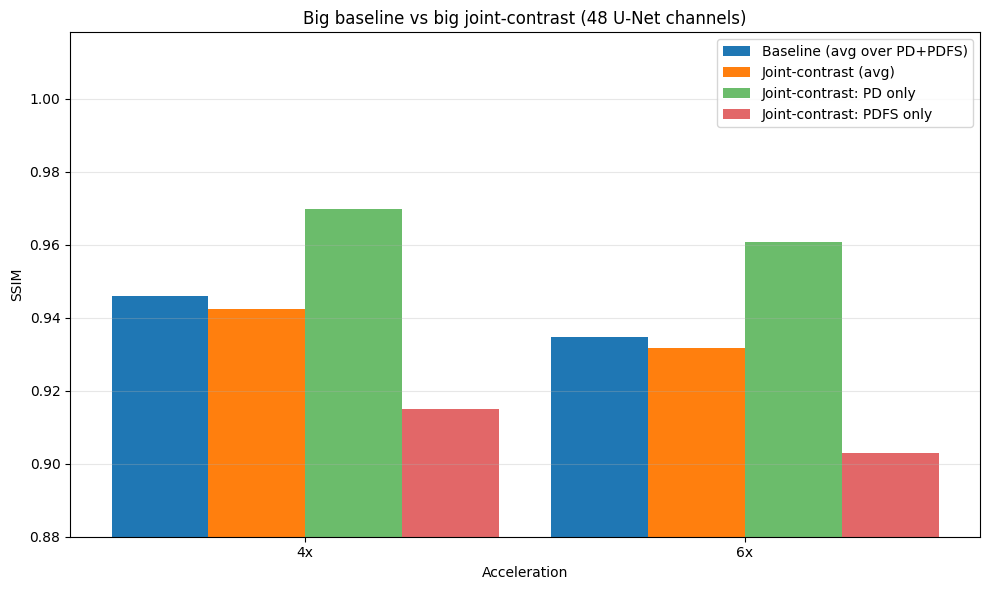

In [7]:
# Bar chart with PD, PDFS broken out
fig, ax = plt.subplots(figsize=(10, 6))
accels = [4, 6]
x = np.arange(len(accels))
width = 0.22

baseline_means = [baseline_results[a][0] for a in accels]
pd_means       = [jc_results[a]['pd'][0]  for a in accels]
pdfs_means     = [jc_results[a]['pdfs'][0] for a in accels]
combined_means = [jc_results[a]['combined'][0] for a in accels]

ax.bar(x - 1.5*width, baseline_means, width, label='Baseline (avg over PD+PDFS)')
ax.bar(x - 0.5*width, combined_means, width, label='Joint-contrast (avg)')
ax.bar(x + 0.5*width, pd_means,       width, label='Joint-contrast: PD only', alpha=0.7)
ax.bar(x + 1.5*width, pdfs_means,     width, label='Joint-contrast: PDFS only', alpha=0.7)

ax.set_xlabel('Acceleration')
ax.set_ylabel('SSIM')
ax.set_title('Big baseline vs big joint-contrast (48 U-Net channels)')
ax.set_xticks(x); ax.set_xticklabels([f'{a}x' for a in accels])
ax.set_ylim(bottom=0.88)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2 — Visual comparison (6x, PD output)

Shows one mid-volume slice reconstructed by each model at 6x acceleration — ground truth, baseline recon, joint-contrast recon, and error maps scaled by `max_value`.

In [ ]:
def show_recon(gt, recon, ssim_val, max_value, title=""):
    error = np.abs(recon - gt) / max_value
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(gt, cmap='gray'); axes[0].set_title('Ground truth'); axes[0].axis('off')
    axes[1].imshow(recon, cmap='gray'); axes[1].set_title(f'{title}\nSSIM={ssim_val:.4f}'); axes[1].axis('off')
    axes[2].imshow(error, cmap='hot', vmin=0, vmax=0.1); axes[2].set_title('Error (% of max)'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()


ds_vis = PairedContrastDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
    mask_type='random', center_fractions=[0.08], accelerations=[6],
    use_seed=True,
)

# Find a mid-volume slice
sample = None
for idx, (_, _, sl, _) in enumerate(ds_vis.examples):
    if sl >= 15:
        sample = ds_vis[idx]
        break

(ksp, msk, tgt_pd, tgt_pdfs, pd_mv, pdfs_mv, pd_fn, pdfs_fn, sl, nlf) = sample

# Find matching PD slice in single-slice dataset for baseline
ss_ds = FastMRIKneeDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
    mask_type='random', center_fractions=[0.08], accelerations=[6],
    use_seed=True,
)
ss_idx = next(i for i, ex in enumerate(ss_ds.examples) if ex[0] == pd_fn and ex[1] == sl)
ss_ksp, ss_msk, ss_tgt, ss_mv, _, _, ss_nlf = ss_ds[ss_idx]

with torch.no_grad():
    outs = big_jc(ksp.unsqueeze(0).to(device), msk.unsqueeze(0).to(device),
                  num_low_frequencies=int(nlf))
    jc_recon_pd = outs[0][0].cpu().numpy()
    base_recon = big_baseline(ss_ksp.unsqueeze(0).to(device), ss_msk.unsqueeze(0).to(device),
                               num_low_frequencies=int(ss_nlf))[0].cpu().numpy()

target_np = tgt_pd.numpy()
ss_ssim = ssim_metric(torch.from_numpy(base_recon), tgt_pd, max_value=float(pd_mv))
jc_ssim = ssim_metric(torch.from_numpy(jc_recon_pd), tgt_pd, max_value=float(pd_mv))

ss_err = np.abs(base_recon - target_np) / float(pd_mv)
jc_err = np.abs(jc_recon_pd - target_np) / float(pd_mv)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(target_np, cmap='gray'); axes[0, 0].set_title('Ground truth (PD)'); axes[0, 0].axis('off')
axes[0, 1].imshow(base_recon, cmap='gray'); axes[0, 1].set_title(f'Big baseline\nSSIM={ss_ssim:.4f}'); axes[0, 1].axis('off')
axes[0, 2].imshow(jc_recon_pd, cmap='gray'); axes[0, 2].set_title(f'Big joint-contrast (PD output)\nSSIM={jc_ssim:.4f}  (\u0394={jc_ssim-ss_ssim:+.4f})'); axes[0, 2].axis('off')

axes[1, 0].imshow(target_np, cmap='gray'); axes[1, 0].set_title('Ground truth'); axes[1, 0].axis('off')
axes[1, 1].imshow(ss_err, cmap='hot', vmin=0, vmax=0.1); axes[1, 1].set_title('Baseline error (% of max)'); axes[1, 1].axis('off')
axes[1, 2].imshow(jc_err, cmap='hot', vmin=0, vmax=0.1); axes[1, 2].set_title('Joint-contrast error (% of max)'); axes[1, 2].axis('off')

plt.suptitle(f'Big models at 6x (PD, slice {sl})', fontsize=12)
plt.tight_layout()
plt.show()

---
## Takeaway

Compare the results here with Lab 2:
- **Small models (24 ch)**: joint-contrast and multislice was worse than baseline.
- **Big models (48 ch)**: the gap widens because the bigger U-Net now has enough capacity to propagate information from all 12 input channels.

The teaching point: **richer input representations only help when the model has enough capacity to use them.** Adding 3 slices or 2 contrasts to a too-small network is wasted input.